In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## VQA from GPT

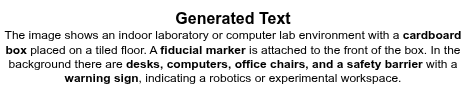

## SAM3 Instance Segmentation

In [ ]:
!pip install --upgrade pip setuptools wheel
!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

!git clone https://github.com/facebookresearch/sam3.git
%cd sam3

!pip install -e .
!pip install -e ".[notebooks]"

In [ ]:
!pip install -U pip
!pip install setuptools==69.5.1
!pip install hydra-core timm opencv-python einops

### After Restart

In [ ]:
%cd /kaggle/working/sam3
!pip install -e .

In [ ]:
from huggingface_hub import login

login(token="your_token")

In [ ]:
%cd /kaggle/working/sam3/sam3
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = '/kaggle/working/sam3/sam3'

In [ ]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [ ]:
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

In [ ]:
image_path = f"your_img_path"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.51)
inference_state = processor.set_image(image)

In [ ]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="chairs")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

## ARuCo Detection

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = 'your_image_path' 
image = cv2.imread(image_path)


dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_1000)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(dictionary, parameters)


corners, ids, rejected_img_points = detector.detectMarkers(image)

print(ids)


if ids is not None:
    
    cv2.aruco.drawDetectedMarkers(image, corners)
    
    for i, marker_id in enumerate(ids):
       
        top_left = (int(corners[i][0][0][0]), int(corners[i][0][0][1]))
        
        cv2.putText(image, 
                    f"ID: {marker_id[0]}", 
                    (top_left[0], top_left[1] - 15), 
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    0.8,              
                    (0, 0, 255),     
                    2,                
                    cv2.LINE_AA)


image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 5. Plot the image
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('ArUco Detection')
plt.show()

## Monocular Depth (Distill Any Depth)

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
from transformers import pipeline


depth_pipe = pipeline(
    task="depth-estimation",
    model="xingyang1/Distill-Any-Depth-Small-hf",
    device=0  # use GPU if available
)

def depth_to_8bit(depth):
    """
    depth: numpy array (H, W), float32
    """
    depth = np.nan_to_num(depth)
    d_min, d_max = depth.min(), depth.max()

    if d_max - d_min < 1e-6:
        return np.zeros_like(depth, dtype=np.uint8)

    depth_norm = (depth - d_min) / (d_max - d_min)
    depth_8bit = (depth_norm * 255).astype(np.uint8)
    return depth_8bit

img_path = 'your_image_path'

image = Image.open(img_path).convert("RGB")

    # Inference
output = depth_pipe(image)
depth = np.array(output["depth"])

    # Convert to 8-bit
depth_8bit = depth_to_8bit(depth)

## Spatial Scene Graphs

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


MAX_DEPTH_METERS = 15.0


G = nx.Graph()


if corners is not None and len(corners) > 0:
    
    aruco_pts = corners[0][0]
    aruco_x = int(np.mean(aruco_pts[:, 0]))
    aruco_y = int(np.mean(aruco_pts[:, 1]))
    
    
    aruco_depth_val = depth_8bit[aruco_y, aruco_x]
    aruco_z_meters = (aruco_depth_val / 255.0) * MAX_DEPTH_METERS
    
    G.add_node('ArUco (Main)', pos=(aruco_x, aruco_y), z=aruco_z_meters, node_type='main')
else:
    print("Warning: No ArUco marker found.")
    aruco_x, aruco_y, aruco_z_meters = 0, 0, 0


for i, mask in enumerate(masks):
    
    y_indices, x_indices = np.where(mask > 0)
    
    if len(y_indices) == 0: 
        continue
        
    chair_x = int(np.mean(x_indices))
    chair_y = int(np.mean(y_indices))
    
    chair_depth_val = np.mean(depth_8bit[mask > 0])
    chair_z_meters = (chair_depth_val / 255.0) * MAX_DEPTH_METERS
    
    node_name = f'Chair_{i+1}'
    G.add_node(node_name, pos=(chair_x, chair_y), z=chair_z_meters, node_type='object')
    
    dz = chair_z_meters - aruco_z_meters
    depth_relation = "Behind" if dz > 0 else "In Front"
    
    dx = chair_x - aruco_x
    lateral_relation = "Right" if dx > 0 else "Left"
    
    edge_label = f"{lateral_relation}, {depth_relation}\n|dz|: {abs(dz):.2f}m"
    
    G.add_edge('ArUco (Main)', node_name, label=edge_label, weight=abs(dz))

plt.figure(figsize=(12, 8))

pos = nx.get_node_attributes(G, 'pos')
plot_pos = {node: (coords[0], -coords[1]) for node, coords in pos.items()}

node_colors = ['#ff9999' if G.nodes[n].get('node_type') == 'main' else '#99ccff' for n in G.nodes]

# Draw nodes and labels
nx.draw(G, plot_pos, with_labels=True, node_color=node_colors, 
        node_size=3000, font_size=10, font_weight='bold', edgecolors='black')

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, plot_pos, edge_labels=edge_labels, font_color='darkgreen', font_size=9)

plt.title("Spatial Scene Graph: ArUco to Chairs")
plt.axis('off')
plt.show()